# Split coverage: old gastronorm vs four_objs

Why did `bb-four-objs-v1` score so much higher than the old gastronorm run? Hypothesis: the new dataset
is so dense that every eval position has a training example almost on top of it, so eval is closer to
lookup than to generalisation. This notebook tests that:

1. **Where train and eval objects sit** (2x2: rows = old / new dataset, columns = train / eval).
2. **Distance** from each eval position's centre of mass to the nearest train one.
3. **Per object, one object in the box at a time**: mask contours + average centre of mass.
4. **Nearest-neighbour mask IoU** (an oracle lookup that pastes the best-overlapping train mask) vs the model.
5. **An honest lookup baseline**: nearest train sample by the model's own INPUT features, paste its mask.

**The two runs compared** have identical settings (boombox, d_model 1024, batch 256, ce-pixel, 1000 epochs,
patch 32, magnitude, bilinear, 32x32 output):
* old: `bb-boxes-gastro-v2` on `31_07_2026_gastronorm_exp1`
* new: `bb-four-objs-v1` on `2026_09_27_gastronorm_four_objs`

**Train/eval come from the runs themselves.** Eval = the sample ids in each run's saved eval predictions;
the old run used an OLDER version of the `gastronorm` split (commit 10a0289: it also had `red-cube` and
`*-speaker` eval sets). `*-speaker` sets are dropped everywhere here: their positions were in train (only
that one speaker was held out), so they are not held-out positions.

**Coordinates.** Centres of mass (`coms`, (row, col) in cropped-overhead pixels) are divided by the crop
WIDTH, so x runs 0-1 across the box and distances are "% of box width" in both datasets. One cell of the
32x32 output is 1/32 = 3.1% of the box width.

# 1 Import

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

REPO = Path.cwd().parent
sys.path[:0] = [str(REPO / "src"), str(REPO)]
from model.dataset import collect_samples, gastronorm_four_objs_2
from utils.metrics import soft_iou

pd.set_option("display.width", 220, "display.max_columns", 40)
EXPERIMENTS_DIR, RUNS_DIR = REPO / "experiments", REPO / "runs"
DATASETS = {  # label: (experiment dir, run)
    "old gastronorm": ("31_07_2026_gastronorm_exp1", "bb-boxes-gastro-v2"),
    "new four_objs": ("2026_09_27_gastronorm_four_objs", "bb-four-objs-v1"),
}
# the old run's split (gastronorm @ 10a0289): these layouts were train, minus its held-out eval samples
OLD_TRAIN_LAYOUTS = {"empty-box", "purple--green-cube-grid1", "purple--green-cube-grid2", "purple--green-cube-grid3",
                     "x-shift", "y-shift", "purple-cube", "purple--green-cube-grid4"}
CELL = 1 / 32

# 2 Style

Colour follows the OBJECT, the same in every panel and both datasets (one cube is blue everywhere), in the
reference palette's fixed order. Eval-only objects (lid, cylinders, coffee pot, sideways soap dispenser)
fold into one neutral grey so no chart needs more than 8 hues.

In [2]:
GROUP_COLOR = {
    "one cube": "#2a78d6", "two cubes": "#eb6834", "vase": "#1baf7a", "candle": "#eda100",
    "soap dispenser": "#e87ba4", "cube + vase": "#008300", "three cubes": "#4a3aa7",
    "eval-only objects": "#898781",
}
INK, INK2, MUTED, GRID, SURFACE, TRAIN_GREY = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb", "#aeada6"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "legend.frameon": False,
})

def group_of(layout: str) -> str | None:
    """Object family of a layout, across both datasets. None = empty box (nothing to localise)."""
    if layout.startswith("empty"): return None
    if layout in ("red-cube-lid", "cylinder-1000g", "cylinder-500g", "cylinder-100g", "coffee-pot",
                  "soap-dispenser-sideways"): return "eval-only objects"
    if layout in ("purple-cube", "red-cube", "lid-purple-cube") or layout.startswith("red-cube-grid"): return "one cube"
    if layout.startswith(("purple--green-cube-grid", "two-cubes-grid")) or layout in ("x-shift", "y-shift"): return "two cubes"
    if layout == "purple--green-red-cube": return "three cubes"
    if layout.startswith("vase"): return "vase"
    if layout == "candle": return "candle"
    if layout.startswith("soap-dispenser-grid"): return "soap dispenser"
    if layout == "cube-vase": return "cube + vase"
    raise ValueError(f"no group for layout {layout!r}")

# 3 Load samples, roles and predictions

One row per SAMPLE (`smp`) with its role (`train` / `eval` / `unused`), eval split, 32x32 target mask and,
for eval samples, the run's final-epoch prediction. Then one row per POSITION (`pos`); every speaker at a
position sees the same objects in the same place, so each object's centre of mass is the median over the
position's speakers.

In [3]:
def run_eval(run: str) -> tuple[dict, dict]:
    """{sample_id: eval split} and {sample_id: predicted 32x32 mask}, from the run's newest saved eval epoch."""
    split_of, pred = {}, {}
    for d in sorted((RUNS_DIR / run / "outputs_history" / "eval").iterdir()):
        if d.name.endswith("-speaker"): continue  # positions were in train: not held out
        files = sorted(d.glob("ep*.pt"))
        last = max(f.name.split("-")[0] for f in files)
        for f in (f for f in files if f.name.startswith(last)):
            o = torch.load(f, map_location="cpu", weights_only=False)
            for sid, m in zip(o["info"]["sample_id"].tolist(), o["mask_pred"].float().numpy()):
                split_of[sid], pred[sid] = d.name, m
    return split_of, pred

def speaker_eval_ids(run: str) -> set:
    ids = set()
    for d in (RUNS_DIR / run / "outputs_history" / "eval").glob("*-speaker"):
        for f in d.glob("ep*.pt"): ids |= set(torch.load(f, map_location="cpu", weights_only=False)["info"]["sample_id"].tolist())
    return ids

smp_frames, pos_frames, GEOM = [], [], {}
for label, (exp, run) in DATASETS.items():
    samples = collect_samples(EXPERIMENTS_DIR / exp / "samples", verbose=0)
    index = [m for _, m in samples]
    eval_split, pred = run_eval(run)
    if label == "new four_objs":  # the run used gastronorm_four_objs (== _2); check that it matches
        sp = gastronorm_four_objs_2(None, verbose=0, index=index)
        train_ids = {int(index[i]["sample_id"]) for i in sp["train"]}
        assert {int(index[i]["sample_id"]) for k, v in sp.items() if k != "train" for i in v} == set(eval_split)
    else:
        spk = speaker_eval_ids(run)
        train_ids = {int(m["sample_id"]) for m in index if m["layout"] in OLD_TRAIN_LAYOUTS} - set(eval_split) - spk
    W, H = Image.open(samples[0][0] / "image/02_cropped_overhead.png").size
    empty = next(d for d, m in samples if m["layout"].startswith("empty") and (d / "image/02_cropped_overhead.png").exists())
    GEOM[label] = dict(W=W, H=H, photo=np.asarray(Image.open(empty / "image/02_cropped_overhead.png").convert("RGB")))
    rows = []
    for d, m in samples:
        sid = int(m["sample_id"])
        role = "eval" if sid in eval_split else "train" if sid in train_ids else "unused"
        coms = np.array(m.get("coms") or [], dtype=float).reshape(-1, 2)
        rows.append(dict(dataset=label, sample_id=sid, position_id=m["position_id"], speaker=m["speaker"],
                         layout=m["layout"], group=group_of(m["layout"]), role=role,
                         split=eval_split.get(sid, role), dir=d, coms=coms,
                         target=np.load(d / "image/04_downsampled_smask_32h_32w.npy").astype(np.float32),
                         pred=pred.get(sid)))
    smp_frames.append(pd.DataFrame(rows))
smp = pd.concat(smp_frames, ignore_index=True)
smp["model_iou"] = [float(soft_iou(p, g)) if p is not None else np.nan for p, g in zip(smp.pred, smp["target"])]

# one row per position (skip empty boxes and samples no split used)
rows = []
for (label, p), s in smp[(smp.role != "unused") & smp.group.notna()].groupby(["dataset", "position_id"]):
    roles = set(s.role)
    assert len(roles) == 1, f"{label} position {p} is both train and eval: whole-position split violated"
    coms = [c for c in s.coms if len(c)]
    coms = [c for c in coms if len(c) == len(coms[0])]
    rc = np.median(np.stack(coms), axis=0)
    W = GEOM[label]["W"]
    rows.append(dict(dataset=label, position_id=p, layout=s.layout.iloc[0], group=s.group.iloc[0],
                     role=roles.pop(), split=s.split.iloc[0], n_objects=len(rc), n_samples=len(s),
                     xy=np.c_[rc[:, 1], rc[:, 0]] / W, dir=s.dir.iloc[0]))
pos = pd.DataFrame(rows)
pos.groupby(["dataset", "role"]).agg(positions=("position_id", "size"), samples=("n_samples", "sum"),
                                     objects=("n_objects", "sum"))

positions  samples  objects
dataset        role                              
new four_objs  eval         282     1410      306
               train        941     4701     1038
old gastronorm eval          36      288       58
               train        330     2522      604

# 4 Plot 1: where train and eval objects sit

Rows: old / new dataset. Columns: train / eval. Each dot is one object at one position (a two-cube
position is two dots), coloured by object. The faint photo is an empty box from that dataset.

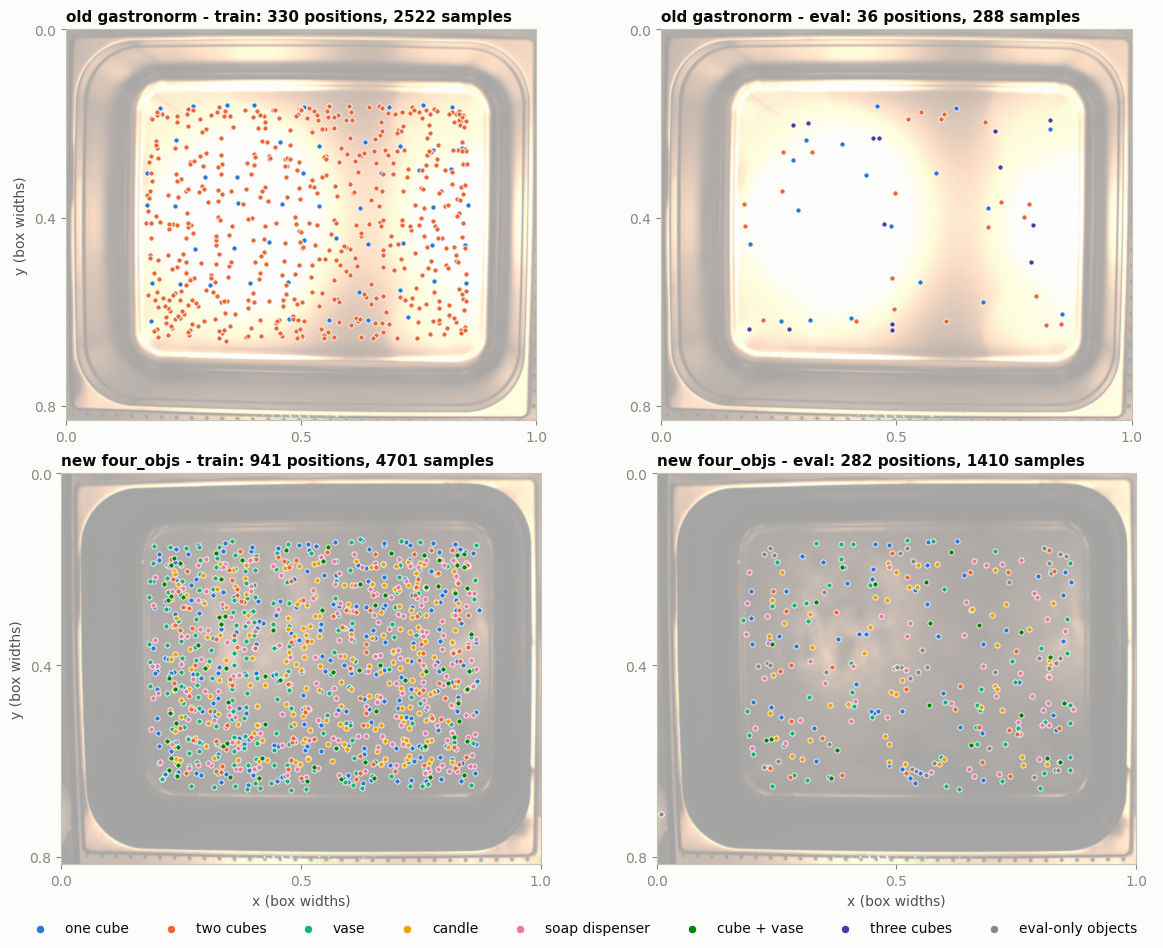

In [4]:
def draw_box(ax, label):
    g = GEOM[label]
    ax.imshow(g["photo"], extent=(0, 1, g["H"] / g["W"], 0), alpha=0.35)
    ax.set_xlim(0, 1); ax.set_ylim(g["H"] / g["W"], 0); ax.set_aspect("equal")
    ax.set_xticks([0, 0.5, 1]); ax.set_yticks([0, 0.4, 0.8])

def scatter_objects(ax, d, size=14):
    for grp, sub in d.groupby("group", sort=False):
        xy = np.concatenate(sub["xy"].to_list())
        ax.scatter(xy[:, 0], xy[:, 1], s=size, color=GROUP_COLOR[grp], edgecolor=SURFACE, linewidth=0.6,
                   label=grp, zorder=3)

fig, axes = plt.subplots(2, 2, figsize=(12, 9.4), constrained_layout=True)
for r, label in enumerate(DATASETS):
    for c, role in enumerate(["train", "eval"]):
        ax, d = axes[r, c], pos[(pos.dataset == label) & (pos.role == role)]
        draw_box(ax, label)
        scatter_objects(ax, d)
        ax.set_title(f"{label} - {role}: {len(d)} positions, {d.n_samples.sum()} samples", loc="left")
        if c == 0: ax.set_ylabel("y (box widths)")
        if r == 1: ax.set_xlabel("x (box widths)")
handles = {h.get_label(): h for ax in axes.flat for h in ax.get_legend_handles_labels()[0]}
fig.legend([handles[g] for g in GROUP_COLOR if g in handles], [g for g in GROUP_COLOR if g in handles],
           loc="outside lower center", ncol=len(handles), markerscale=1.6)
plt.show()

# 5 Plot 2: distance from each eval position to the nearest train position

For every object at an eval position: the distance from its centre of mass to the nearest train object's
centre of mass. A position's value is the mean over its objects.
* **any object** - how close the nearest seen spot is, whatever was there.
* **same object** - nearest train position of the SAME object (the eval-only objects never appear in
  train, so they have none).

The dashed line is one 32x32 output cell (3.1% of the box width). The x axis is capped at 8%; the few
positions beyond it (the red cube on the lid, whose centre of mass sits at the box edge) are pinned to the
right edge.

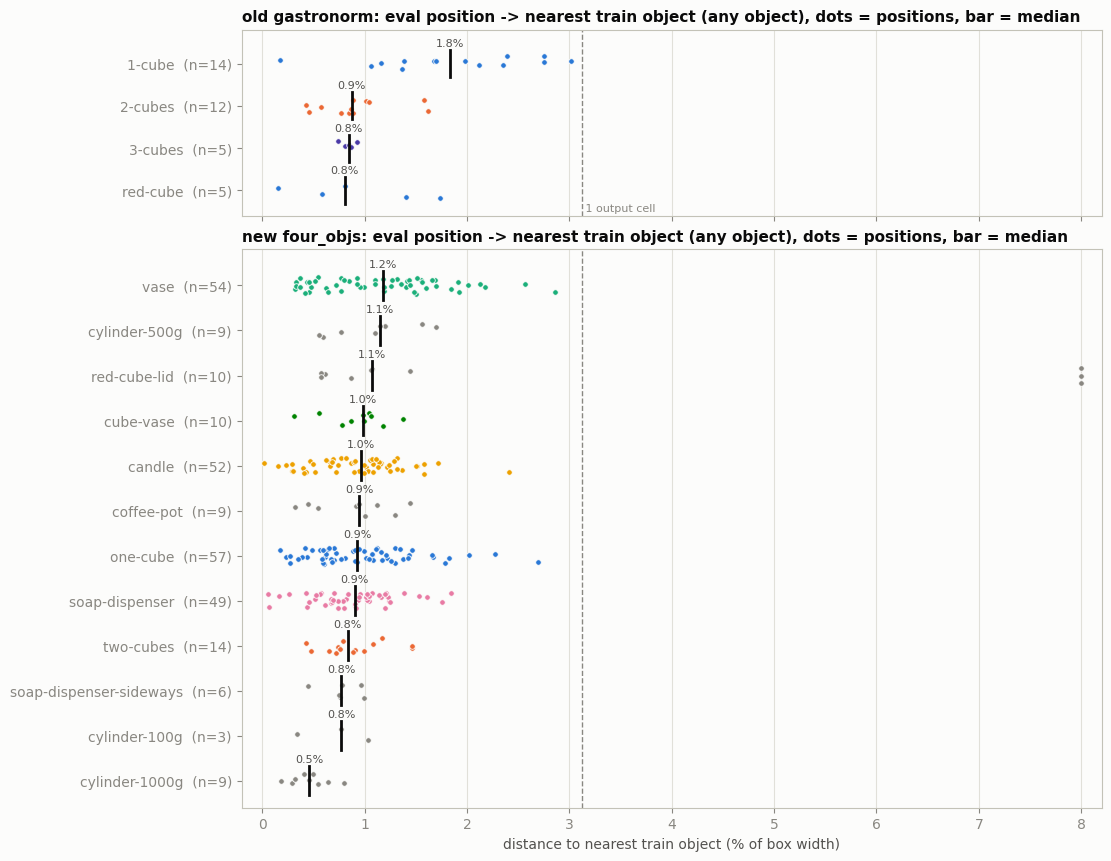

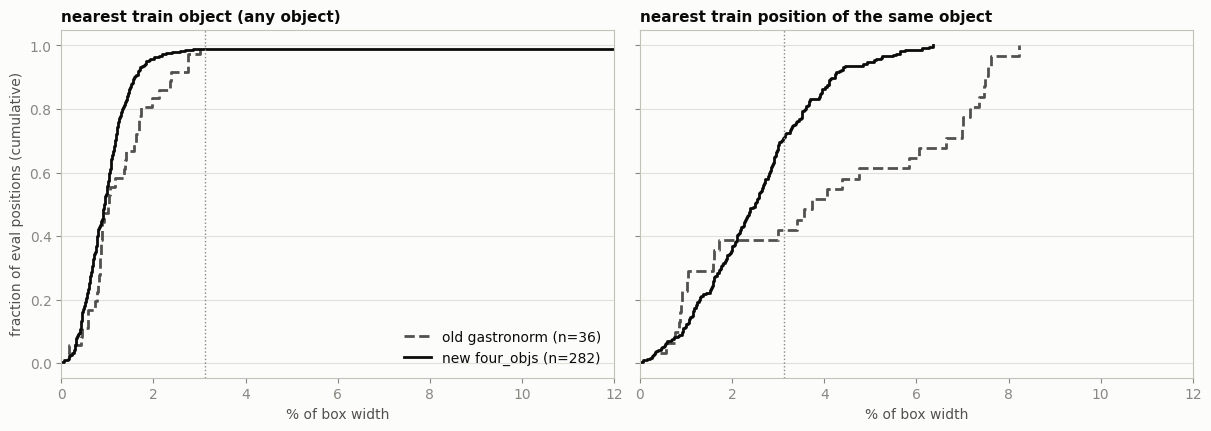

positions  any_median_pct  same_median_pct within_1_cell
dataset        split                                                                            
new four_objs  candle                          52            0.97             1.81          100%
               coffee-pot                       9            0.95              NaN          100%
               cube-vase                       10            0.99             3.91          100%
               cylinder-1000g                   9            0.46              NaN          100%
               cylinder-100g                    3            0.77              NaN          100%
               cylinder-500g                    9            1.15              NaN          100%
               one-cube                        57            0.93             2.56          100%
               red-cube-lid                    10            1.07              NaN           70%
               soap-dispenser                  49            0.91             2.06          100%
               soap-dispenser-sideways          6            0.77              NaN          100%
               two-cubes                       14            0.84             2.58          100%
               vase                            54            1.18             2.91          100%
old gastronorm 1-cube                          14            1.84             7.08          100%
               2-cubes                         12            0.88             0.90          100%
               3-cubes                          5            0.85              NaN          100%
               red-cube                         5            0.81             3.57          100%

In [5]:
def nearest(xy_eval, train_xy):
    d = np.linalg.norm(xy_eval[:, None, :] - train_xy[None, :, :], axis=-1)  # (objects, train objects)
    return d.min(axis=1).mean()

rows = []
for label in DATASETS:
    d = pos[pos.dataset == label]
    train = d[d.role == "train"]
    all_train = np.concatenate(train["xy"].to_list())
    for _, e in d[d.role == "eval"].iterrows():
        same = train[train.group == e.group]
        rows.append(dict(dataset=label, split=e.split, group=e.group, position_id=e.position_id,
                         any_object=nearest(e.xy, all_train),
                         same_object=nearest(e.xy, np.concatenate(same["xy"].to_list())) if len(same) else np.nan))
nn = pd.DataFrame(rows)

XMAX = 8
fig, axes = plt.subplots(2, 1, figsize=(11, 8.5), constrained_layout=True, sharex=True,
                         gridspec_kw={"height_ratios": [nn[nn.dataset == l].split.nunique() for l in DATASETS]})
rng = np.random.default_rng(0)
for ax, label in zip(axes, DATASETS):
    d = nn[nn.dataset == label]
    order = d.groupby("split")["any_object"].median().sort_values().index.tolist()
    for k, name in enumerate(order):
        s = d[d.split == name]
        y = k + rng.uniform(-0.18, 0.18, len(s))
        ax.scatter(np.minimum(s.any_object * 100, XMAX), y, s=16, color=GROUP_COLOR[s.group.iloc[0]],
                   edgecolor=SURFACE, linewidth=0.6, zorder=3)
        med = s.any_object.median() * 100
        ax.plot([med, med], [k - 0.32, k + 0.32], color=INK, linewidth=2, zorder=4)
        ax.text(med, k + 0.36, f"{med:.1f}%", ha="center", va="bottom", fontsize=8, color=INK2)
    ax.axvline(CELL * 100, color=MUTED, linestyle="--", linewidth=1)
    ax.set_yticks(range(len(order)), [f"{n}  (n={len(d[d.split == n])})" for n in order])
    ax.set_ylim(-0.6, len(order) - 0.2)
    ax.set_title(f"{label}: eval position -> nearest train object (any object), dots = positions, bar = median", loc="left")
    ax.xaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
axes[0].text(CELL * 100, -0.55, " 1 output cell", color=MUTED, fontsize=8, va="bottom")
axes[-1].set_xlim(-0.2, XMAX + 0.2)
axes[-1].set_xlabel("distance to nearest train object (% of box width)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True, sharey=True)
styles = {"old gastronorm": dict(color=INK2, linestyle="--"), "new four_objs": dict(color=INK, linestyle="-")}
for ax, col, title in zip(axes, ["any_object", "same_object"], ["nearest train object (any object)", "nearest train position of the same object"]):
    for label in DATASETS:
        v = np.sort(nn.loc[nn.dataset == label, col].dropna().to_numpy() * 100)
        ax.step(v, np.arange(1, len(v) + 1) / len(v), where="post", linewidth=2, label=f"{label} (n={len(v)})", **styles[label])
    ax.axvline(CELL * 100, color=MUTED, linestyle=":", linewidth=1)
    ax.set_xlim(0, 12); ax.set_title(title, loc="left"); ax.set_xlabel("% of box width")
    ax.yaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
axes[0].set_ylabel("fraction of eval positions (cumulative)")
axes[0].legend(loc="lower right")
plt.show()

(nn.assign(any_pct=nn.any_object * 100, same_pct=nn.same_object * 100)
   .groupby(["dataset", "split"])
   .agg(positions=("position_id", "size"), any_median_pct=("any_pct", "median"),
        same_median_pct=("same_pct", "median"),
        within_1_cell=("any_object", lambda s: f"{(s < CELL).mean():.0%}"))
   .round(2))

# 6 Plot 3: per object, one object in the box at a time

Single-object positions only. One panel per (dataset, object): every position's **mask contour** (from the
full-resolution segmentation, one speaker's frame per position) plus its **average centre of mass** (dot).
Grey = train positions, colour = eval positions. Where the coloured outlines sit inside a mesh of grey ones,
the model has already been trained to paint almost exactly that shape in almost exactly that place.

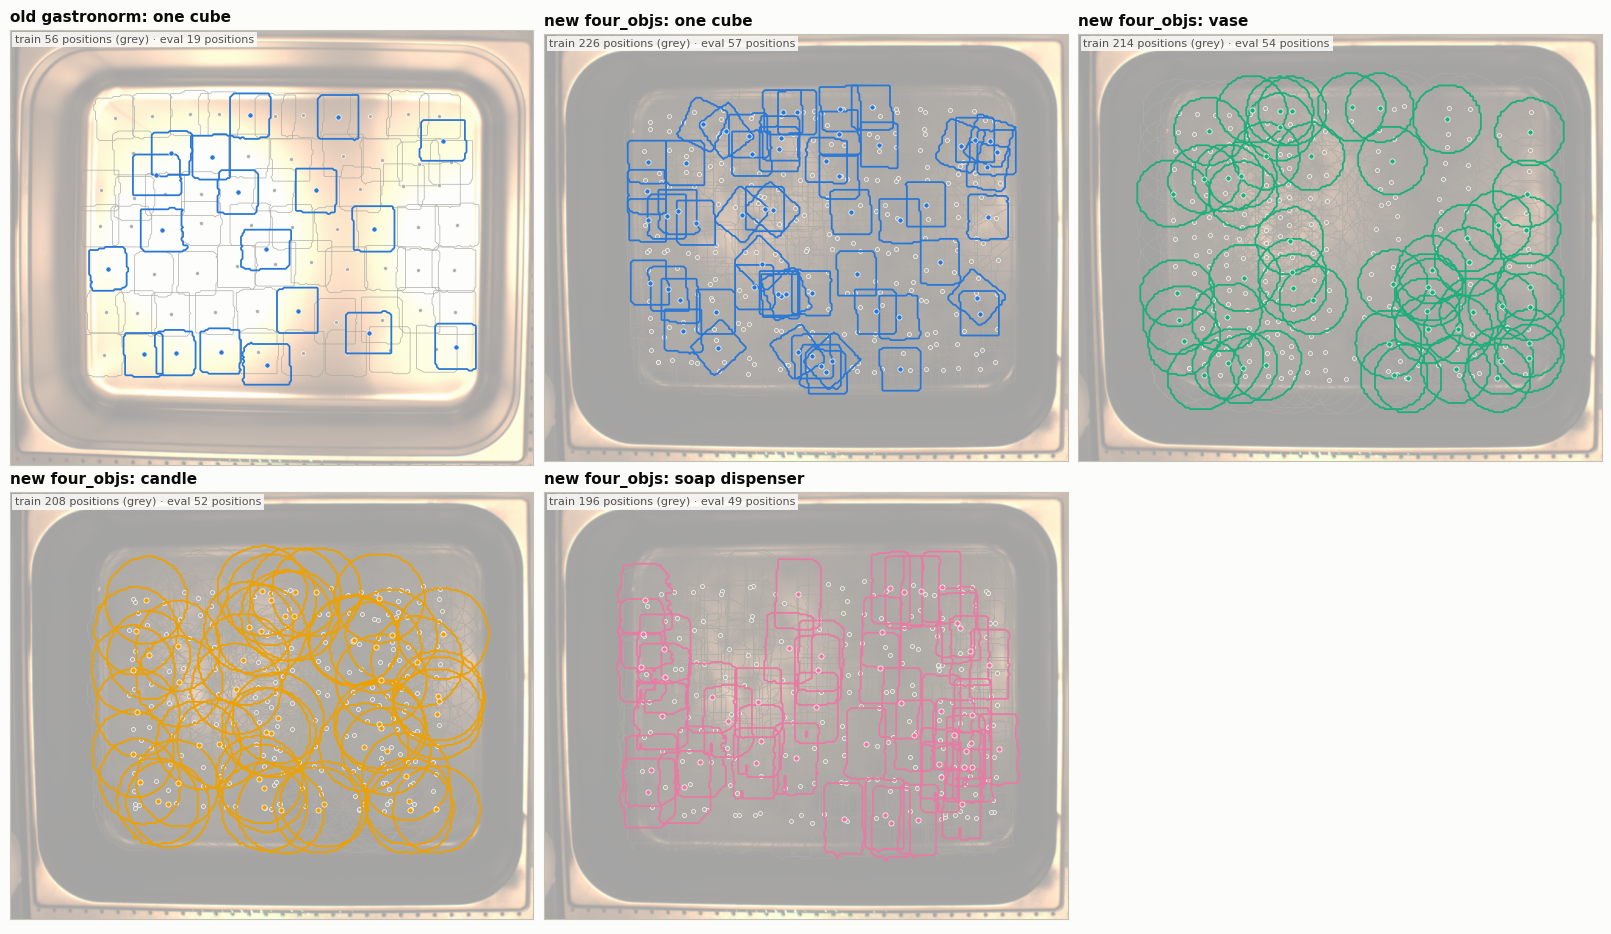

In [6]:
SINGLE = [("old gastronorm", "one cube"), ("new four_objs", "one cube"), ("new four_objs", "vase"),
          ("new four_objs", "candle"), ("new four_objs", "soap dispenser")]
STRIDE = 4  # contour from every 4th full-res pixel: plenty for an outline, 16x less to read

def full_mask(sample_dir):
    m = np.load(sample_dir / "image/03_smask.npy")
    return m[::STRIDE, ::STRIDE].astype(np.float32)

fig, axes = plt.subplots(2, 3, figsize=(16, 9.2), constrained_layout=True)
axes.flat[-1].axis("off")
for ax, (label, g) in zip(axes.flat, SINGLE):
    d = pos[(pos.dataset == label) & (pos.group == g) & (pos.n_objects == 1)]
    W = GEOM[label]["W"]
    draw_box(ax, label)
    for role, color, lw, z in [("train", TRAIN_GREY, 0.5, 2), ("eval", GROUP_COLOR[g], 1.3, 4)]:
        s = d[d.role == role]
        for sample_dir in s.dir:
            m = full_mask(sample_dir)
            ys, xs = np.arange(m.shape[0]) * STRIDE / W, np.arange(m.shape[1]) * STRIDE / W
            ax.contour(xs, ys, m, levels=[0.5], colors=[color], linewidths=lw, zorder=z)
        if len(s):
            xy = np.concatenate(s.xy.to_list())
            ax.scatter(xy[:, 0], xy[:, 1], s=8 if role == "train" else 14, color=color, edgecolor=SURFACE,
                       linewidth=0.5, zorder=z + 1)
    n_tr, n_ev = (d.role == "train").sum(), (d.role == "eval").sum()
    ax.set_title(f"{label}: {g}", loc="left")
    ax.text(0.01, 0.99, f"train {n_tr} positions (grey) · eval {n_ev} positions", transform=ax.transAxes,
            va="top", fontsize=8, color=INK2, bbox=dict(facecolor=SURFACE, edgecolor="none", alpha=0.85, pad=2))
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

# 7 Nearest-neighbour mask IoU vs the model

For each eval sample: the highest soft IoU (`utils.metrics.soft_iou`, the training metric) between its
32x32 target and any TRAIN target of the same object. That is exactly what a lookup would score if it could
pick the best-overlapping training mask and paste it in: an **oracle** (it chooses by looking at the answer),
so it is an upper bound on lookup, and it measures overlap in the model's own output grid, where object size
matters automatically (a big vase 3% away still covers most of the same cells; a cube does not).

Points ABOVE the diagonal: the model beats the best possible paste-a-training-mask. ON or BELOW: the model
does no better than lookup. Eval-only objects have no same-object training masks, so they are not shown.

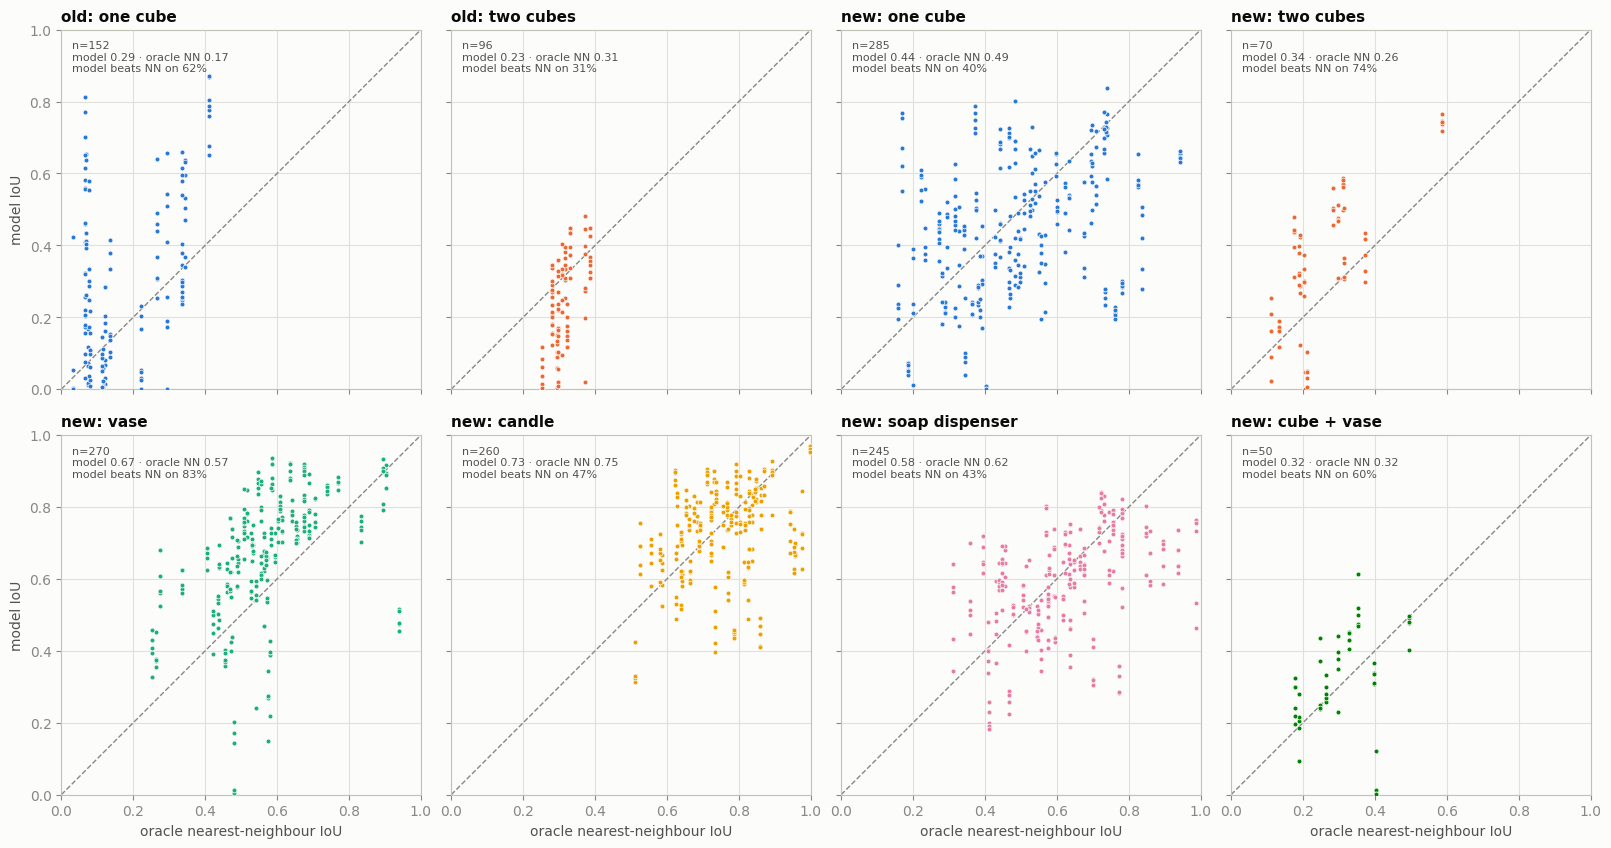

In [7]:
def best_overlap(gt, train_gts):
    """(max soft IoU, argmax) of one target against a stack of train targets, both flattened."""
    s = np.minimum(train_gts, gt).sum(1) / np.maximum(np.maximum(train_gts, gt).sum(1), 1e-6)
    return s.max(), s.argmax()

smp["nn_iou"] = np.nan
for label in DATASETS:
    d = smp[smp.dataset == label]
    for g, e in d[(d.role == "eval") & d.group.notna()].groupby("group"):
        tr = d[(d.role == "train") & (d.group == g)]
        if not len(tr): continue
        T = np.stack(tr["target"].to_list()).reshape(len(tr), -1)
        smp.loc[e.index, "nn_iou"] = [best_overlap(gt.reshape(-1), T)[0] for gt in e["target"]]

panels = [(l, g) for l in DATASETS for g in GROUP_COLOR
          if ((smp.dataset == l) & (smp.group == g) & smp.nn_iou.notna()).any()]
fig, axes = plt.subplots(2, 4, figsize=(16, 8.4), constrained_layout=True, sharex=True, sharey=True)
for ax in axes.flat[len(panels):]: ax.axis("off")
for ax, (label, g) in zip(axes.flat, panels):
    s = smp[(smp.dataset == label) & (smp.group == g) & smp.nn_iou.notna()]
    ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, linestyle="--", zorder=1)
    ax.scatter(s.nn_iou, s.model_iou, s=12, color=GROUP_COLOR[g], edgecolor=SURFACE, linewidth=0.5, zorder=3)
    above = (s.model_iou > s.nn_iou).mean()
    ax.set_title(f"{label.split()[0]}: {g}", loc="left")
    ax.text(0.03, 0.97, f"n={len(s)}\nmodel {s.model_iou.mean():.2f} · oracle NN {s.nn_iou.mean():.2f}\nmodel beats NN on {above:.0%}",
            transform=ax.transAxes, va="top", fontsize=8, color=INK2)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
    ax.xaxis.grid(True, color=GRID, linewidth=0.8); ax.yaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
for ax in axes[-1]: ax.set_xlabel("oracle nearest-neighbour IoU")
for ax in axes[:, 0]: ax.set_ylabel("model IoU")
plt.show()

# 8 An honest lookup baseline: nearest neighbour in INPUT space

The oracle above cheats: it picks the neighbour by comparing target masks, which the model never sees. This
baseline only uses what the model gets: each sample's precomputed input
(`vibration/05_precomputed_fft_magnitude_std_32.npy`, magnitude, std-normalised, 32-bin patches), pooled
over each patch -> one number per (laser, patch, channel), z-scored on the train set. For each eval sample:
the k most cosine-similar TRAIN samples (any object, any speaker, including empty boxes - the model's whole
train set), and the prediction is the mean of their target masks.

If this lookup lands close to the model, the task on this split is mostly lookup.

In [8]:
def features(sample_dir):
    x = np.load(sample_dir / "vibration/05_precomputed_fft_magnitude_std_32.npy")  # (L, P, 32, C)
    return x.mean(axis=2).reshape(-1)                                               # (L*P*C,)

K = (1, 5)
for k in K: smp[f"knn{k}_iou"] = np.nan
for label in DATASETS:
    d = smp[smp.dataset == label]
    tr, ev = d[d.role == "train"], d[d.role == "eval"]
    Xtr = np.stack([features(p) for p in tr.dir]); Xev = np.stack([features(p) for p in ev.dir])
    mu, sd = Xtr.mean(0), Xtr.std(0) + 1e-6
    Xtr, Xev = (Xtr - mu) / sd, (Xev - mu) / sd
    Xtr /= np.linalg.norm(Xtr, axis=1, keepdims=True); Xev /= np.linalg.norm(Xev, axis=1, keepdims=True)
    order = np.argsort(-(Xev @ Xtr.T), axis=1)                                    # (eval, train) nearest first
    Ytr = np.stack(tr["target"].to_list())
    for k in K:
        preds = Ytr[order[:, :k]].mean(axis=1)
        smp.loc[ev.index, f"knn{k}_iou"] = [float(soft_iou(p, g)) for p, g in zip(preds, ev["target"])]

ev_all = smp[smp.role == "eval"]
table = (ev_all.groupby(["dataset", "split"])
         .agg(samples=("sample_id", "size"), model=("model_iou", "mean"), knn1=("knn1_iou", "mean"),
              knn5=("knn5_iou", "mean"), oracle_nn=("nn_iou", "mean"))
         .round(3))
table

samples  model   knn1   knn5  oracle_nn
dataset        split                                                           
new four_objs  candle                       260  0.728  0.556  0.479      0.753
               coffee-pot                    45  0.410  0.327  0.285        NaN
               cube-vase                     50  0.318  0.235  0.156      0.315
               cylinder-1000g                45  0.277  0.152  0.159        NaN
               cylinder-100g                 15  0.044  0.001  0.012        NaN
               cylinder-500g                 45  0.132  0.043  0.048        NaN
               one-cube                     285  0.442  0.182  0.140      0.485
               red-cube-lid                  50  0.237  0.116  0.115        NaN
               soap-dispenser               245  0.584  0.362  0.307      0.618
               soap-dispenser-sideways       30  0.431  0.252  0.292        NaN
               two-cubes                     70  0.339  0.137  0.115      0.256
               vase                         270  0.666  0.454  0.369      0.569
old gastronorm 1-cube                       112  0.210  0.078  0.068      0.113
               2-cubes                       96  0.233  0.128  0.098      0.311
               3-cubes                       40  0.159  0.131  0.090        NaN
               red-cube                      40  0.509  0.161  0.119      0.330

Same numbers as a dot plot: per eval set, the model (filled circle), the input-space lookup (k=5, open
square) and the oracle nearest-neighbour mask (grey tick, 80/20 objects only). The gap between the model and
the k=5 lookup is what the model adds beyond "find the most similar training recording".

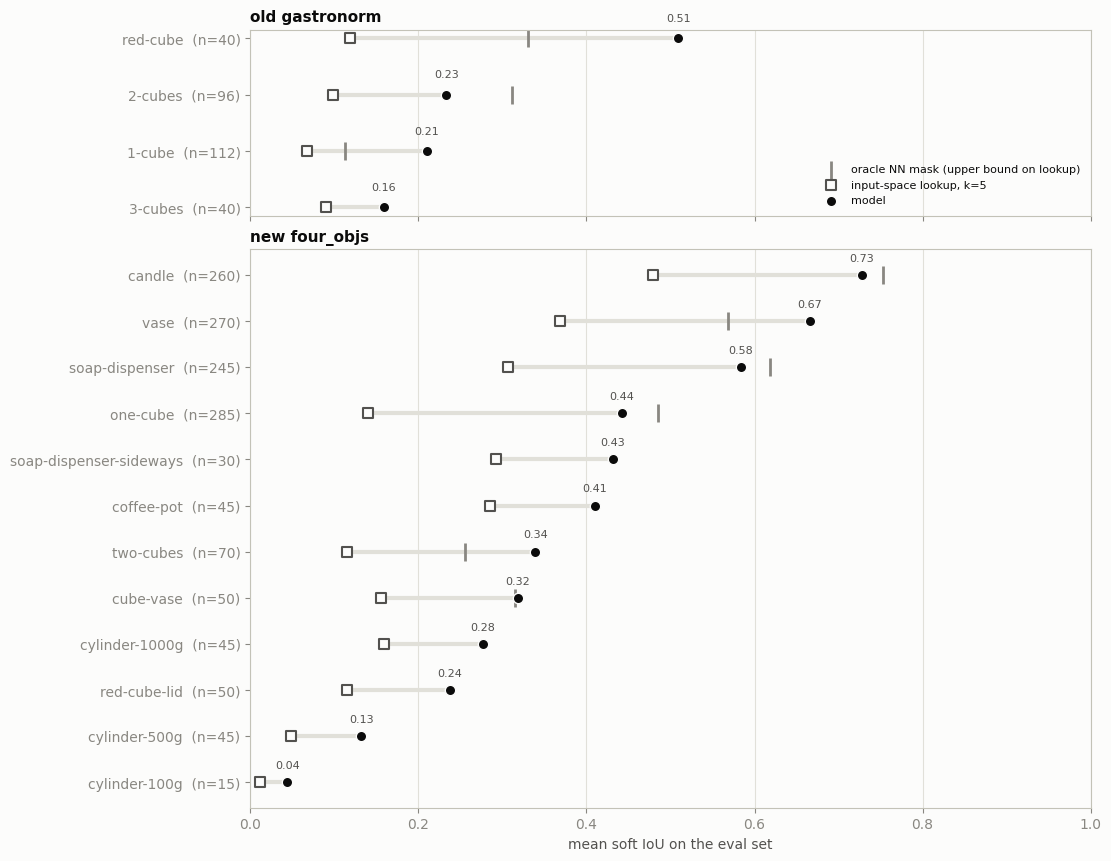

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8.5), constrained_layout=True, sharex=True,
                         gridspec_kw={"height_ratios": [ev_all[ev_all.dataset == l].split.nunique() for l in DATASETS]})
for ax, label in zip(axes, DATASETS):
    t = table.loc[label].sort_values("model")
    y = np.arange(len(t))
    ax.hlines(y, t[["knn5", "model"]].min(axis=1), t[["knn5", "model"]].max(axis=1), color=GRID, linewidth=3, zorder=1)
    ax.scatter(t.oracle_nn, y, marker="|", s=160, color=MUTED, linewidth=2, zorder=2, label="oracle NN mask (upper bound on lookup)")
    ax.scatter(t.knn5, y, marker="s", s=48, facecolor=SURFACE, edgecolor=INK2, linewidth=1.5, zorder=3, label="input-space lookup, k=5")
    ax.scatter(t.model, y, s=56, color=INK, edgecolor=SURFACE, linewidth=1, zorder=4, label="model")
    for yi, (name, r) in zip(y, t.iterrows()):
        ax.text(r.model, yi + 0.3, f"{r.model:.2f}", ha="center", fontsize=8, color=INK2)
    ax.set_yticks(y, [f"{n}  (n={int(r.samples)})" for n, r in t.iterrows()])
    ax.set_title(label, loc="left")
    ax.xaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
axes[0].legend(loc="lower right", fontsize=8)
axes[-1].set_xlabel("mean soft IoU on the eval set")
axes[-1].set_xlim(0, 1)
plt.show()

# 9 A coarse split by mask overlap: how much training data survives?

The coarse-grid test: keep the eval sets fixed, and for each main object REMOVE every train position whose
mask overlaps any eval mask of the same object with IoU > tau. Compare against a random removal of the
same number of positions, so both arms have the same amount of data and differ only in how close the
nearest training example is.

Overlap is measured on each position's 32x32 target (mean over its speakers) thresholded at 0.5, so
"overlap" means sharing an occupied output cell and **tau = 0 means no shared cell at all**. Only the SAME
object is excluded; other objects stay in train. For each tau:
* **train kept** - positions and samples of that object left in train (= the size of the random control);
* **eval oracle NN** - the oracle nearest-neighbour IoU from section 7, recomputed against only what is
  kept: how easy eval still is. For reference, the old dataset's single cube was **0.11**.

In [10]:
TAUS = [0.0, 0.1, 0.3, 0.5]
MAIN = ["one cube", "vase", "candle", "soap dispenser"]
OLD_ONE_CUBE_NN = smp[(smp.dataset == "old gastronorm") & (smp.split == "1-cube")].nn_iou.mean()

rows = []
d = smp[smp.dataset == "new four_objs"]
for g in MAIN:
    s = d[(d.group == g) & (d.role != "unused")]
    occ = s.groupby("position_id")["target"].apply(lambda t: (np.mean(np.stack(t.to_list()), 0) > 0.5).reshape(-1))
    role = s.groupby("position_id").role.first()
    tr_pos, ev_pos = role.index[role == "train"].to_numpy(), role.index[role == "eval"].to_numpy()
    Tr = np.stack(occ[tr_pos].to_list()).astype(np.float32); Ev = np.stack(occ[ev_pos].to_list()).astype(np.float32)
    inter = Tr @ Ev.T
    iou = inter / np.maximum(Tr.sum(1)[:, None] + Ev.sum(1)[None, :] - inter, 1)
    worst = iou.max(axis=1)                       # each train position's largest overlap with any eval position
    ev_s = s[s.role == "eval"]
    for tau in [None] + TAUS:
        kept = set(tr_pos if tau is None else tr_pos[worst <= tau])
        tr_s = s[(s.role == "train") & s.position_id.isin(kept)]
        T = np.stack(tr_s["target"].to_list()).reshape(len(tr_s), -1) if len(tr_s) else None
        nn_after = np.mean([best_overlap(t.reshape(-1), T)[0] for t in ev_s["target"]]) if T is not None else 0.0
        rows.append(dict(object=g, tau="all train" if tau is None else f"{tau:g}",
                         train_positions=len(kept), of=len(tr_pos), kept=f"{len(kept) / len(tr_pos):.0%}",
                         train_samples=len(tr_s), eval_oracle_nn=round(nn_after, 3)))
coarse = pd.DataFrame(rows)
print(f"old gastronorm single cube, eval oracle NN for reference: {OLD_ONE_CUBE_NN:.3f}")
coarse.pivot(index="object", columns="tau", values=["train_positions", "kept", "train_samples", "eval_oracle_nn"])[
    [(v, t) for v in ["train_positions", "kept", "train_samples", "eval_oracle_nn"] for t in ["all train"] + [f"{x:g}" for x in TAUS]]]

old gastronorm single cube, eval oracle NN for reference: 0.113


train_positions                        kept                    train_samples                     eval_oracle_nn                            
tau                  all train   0 0.1  0.3  0.5 all train   0  0.1  0.3  0.5     all train    0  0.1  0.3  0.5      all train      0    0.1    0.3    0.5
object                                                                                                                                                    
candle                     208   0   0   15   84      100%  0%   0%   7%  40%          1040    0    0   75  420          0.753    0.0    0.0  0.143  0.424
one cube                   226  21  47  140  199      100%  9%  21%  62%  88%          1126  105  235  696  991          0.485  0.023  0.075  0.249  0.371
soap dispenser             196  10  20   86  154      100%  5%  10%  44%  79%           980   50  100  430  770          0.618  0.006  0.023  0.227  0.419
vase                       214   1  11   59  155      100%  0%   5%  28%  72%          1070    5   55  295  775          0.569  0.001  0.017  0.138  0.424

Left: how much of each object's training data survives. Right: how easy eval still is (oracle nearest-
neighbour IoU against what survives). The dashed line is the old dataset's single cube: a tau whose curve
lands near it makes the new eval as far from training as the old one was.

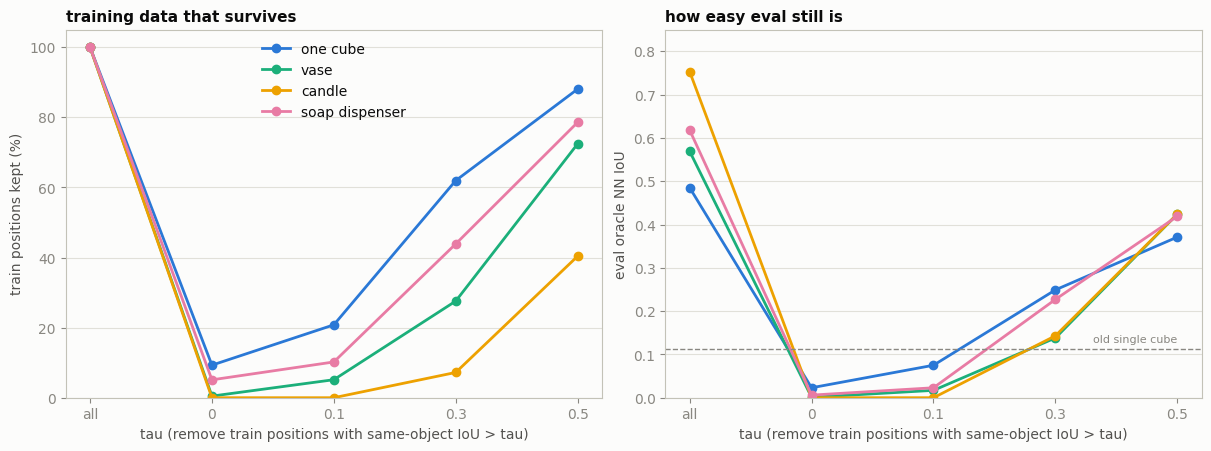

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
xs = np.arange(len(TAUS) + 1)
labels = ["all"] + [f"{t:g}" for t in TAUS]
for g in MAIN:
    c = coarse[coarse.object == g]
    axes[0].plot(xs, 100 * c.train_positions / c["of"], marker="o", color=GROUP_COLOR[g], linewidth=2, markersize=6, label=g)
    axes[1].plot(xs, c.eval_oracle_nn, marker="o", color=GROUP_COLOR[g], linewidth=2, markersize=6, label=g)
axes[1].axhline(OLD_ONE_CUBE_NN, color=MUTED, linestyle="--", linewidth=1)
axes[1].text(xs[-1], OLD_ONE_CUBE_NN + 0.015, "old single cube", ha="right", fontsize=8, color=MUTED)
axes[0].set_ylabel("train positions kept (%)"); axes[0].set_ylim(0, 105)
axes[1].set_ylabel("eval oracle NN IoU"); axes[1].set_ylim(0, 0.85)
for ax, t in zip(axes, ["training data that survives", "how easy eval still is"]):
    ax.set_xticks(xs, labels); ax.set_xlabel("tau (remove train positions with same-object IoU > tau)")
    ax.set_title(t, loc="left"); ax.yaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
axes[0].legend(loc="upper center")
plt.show()